# 02 — Regimes x Morfologia: Kruskal-Wallis (Cap. 6.2)

**H0:** A distribuição de cada indicador é igual entre os três regimes.
**H1:** Ao menos um regime difere.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
df = pd.read_csv('../data/processed/corpus_dataset.csv')
INDICATORS = ['desincorporacao','rigidez_postural','dessexualizacao','uniformizacao_facial','heraldizacao','enquadramento_arquitetonico','apagamento_narrativo','monocromatizacao','serialidade','inscricao_estatal']
INDICATOR_LABELS = {'desincorporacao':'Desincorporação','rigidez_postural':'Rigidez postural','dessexualizacao':'Dessexualização','uniformizacao_facial':'Uniformização facial','heraldizacao':'Heraldicização','enquadramento_arquitetonico':'Enquadramento arq.','apagamento_narrativo':'Apagamento narrativo','monocromatizacao':'Monocromatização','serialidade':'Serialidade','inscricao_estatal':'Inscrição estatal'}
regimes = ['fundacional','normativo','militar']
groups = {r: df[df.regime_iconocratico == r] for r in regimes}

print(f"N por regime: {', '.join(f'{r}={len(g)}' for r, g in groups.items())}")
print(f"{'='*70}")
print(f"{'Indicador':<25s} {'H':>8s} {'p-value':>10s} {'Sig.':>6s} {'eta2':>8s}")
print(f"{'='*70}")
results = []
for ind in INDICATORS:
    samples = [g[ind].dropna().values for g in groups.values()]
    H, p = stats.kruskal(*samples)
    n = sum(len(s) for s in samples)
    eta2 = (H - len(regimes) + 1) / (n - len(regimes))
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    results.append({'indicator': ind, 'H': H, 'p': p, 'sig': sig, 'eta2': eta2})
    print(f"{INDICATOR_LABELS[ind]:<25s} {H:8.2f} {p:10.4f} {sig:>6s} {eta2:8.3f}")
print(f"{'='*70}")
print(f"{sum(1 for r in results if r['p'] < 0.05)}/10 indicadores com diferença significativa")

N por regime: fundacional=57, normativo=28, militar=10
Indicador                        H    p-value   Sig.     eta2
Desincorporação               9.55     0.0084     **    0.082
Rigidez postural             11.58     0.0031     **    0.104
Dessexualização              13.53     0.0012     **    0.125
Uniformização facial         11.11     0.0039     **    0.099
Heraldicização               16.88     0.0002    ***    0.162
Enquadramento arq.            8.14     0.0171      *    0.067
Apagamento narrativo         13.98     0.0009    ***    0.130
Monocromatização             14.53     0.0007    ***    0.136
Serialidade                  35.72     0.0000    ***    0.367
Inscrição estatal            34.34     0.0000    ***    0.352
10/10 indicadores com diferença significativa


## 2.2 Post-hoc Dunn (Bonferroni)

In [2]:
sig_indicators = [r['indicator'] for r in results if r['p'] < 0.05]
for ind in sig_indicators:
    print(f"{'='*50}")
    print(f"  Dunn: {INDICATOR_LABELS[ind]}")
    print(f"{'='*50}")
    dunn = sp.posthoc_dunn(df, val_col=ind, group_col='regime_iconocratico', p_adjust='bonferroni')
    print(dunn.round(4))

print(f"{'='*50}")
print(f"  Kruskal-Wallis: Score composto")
print(f"{'='*50}")
H, p = stats.kruskal(*[groups[r]['purificacao_composto'].values for r in regimes])
print(f"H = {H:.2f}, p = {p:.6f}")
if p < 0.05:
    dunn_comp = sp.posthoc_dunn(df, val_col='purificacao_composto', group_col='regime_iconocratico', p_adjust='bonferroni')
    print(dunn_comp.round(4))

  Dunn: Desincorporação
             fundacional  militar  normativo
fundacional       1.0000   0.2295     0.0126
militar           0.2295   1.0000     1.0000
normativo         0.0126   1.0000     1.0000
  Dunn: Rigidez postural
             fundacional  militar  normativo
fundacional        1.000   1.0000     0.0020
militar            1.000   1.0000     0.4744
normativo          0.002   0.4744     1.0000
  Dunn: Dessexualização
             fundacional  militar  normativo
fundacional       1.0000   0.0784     0.0024
militar           0.0784   1.0000     1.0000
normativo         0.0024   1.0000     1.0000
  Dunn: Uniformização facial
             fundacional  militar  normativo
fundacional       1.0000    0.485     0.0033
militar           0.4850    1.000     1.0000
normativo         0.0033    1.000     1.0000
  Dunn: Heraldicização
             fundacional  militar  normativo
fundacional       1.0000   0.0374     0.0006
militar           0.0374   1.0000     1.0000
normativo         0.

## 2.3 Violinplots por regime

/var/folders/_j/9nc46yj159z2zkp8jhff7rj40000gn/T/ipykernel_57183/3253365742.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='regime_iconocratico', y=ind, order=regimes, palette=palette, ax=ax, inner='quartile', cut=0)
/var/folders/_j/9nc46yj159z2zkp8jhff7rj40000gn/T/ipykernel_57183/3253365742.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['F','N','M'], fontsize=8)
/var/folders/_j/9nc46yj159z2zkp8jhff7rj40000gn/T/ipykernel_57183/3253365742.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='regime_iconocratico', y=ind, order=regimes, palette=palette,

/var/folders/_j/9nc46yj159z2zkp8jhff7rj40000gn/T/ipykernel_57183/3253365742.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['F','N','M'], fontsize=8)
/var/folders/_j/9nc46yj159z2zkp8jhff7rj40000gn/T/ipykernel_57183/3253365742.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='regime_iconocratico', y=ind, order=regimes, palette=palette, ax=ax, inner='quartile', cut=0)
/var/folders/_j/9nc46yj159z2zkp8jhff7rj40000gn/T/ipykernel_57183/3253365742.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['F','N','M'], fontsize=8)
/var/folders/_j/9nc46yj159z2zkp8jhff7rj40000gn/T/ipykernel_57183/3253365742.py:5: FutureWarning

/var/folders/_j/9nc46yj159z2zkp8jhff7rj40000gn/T/ipykernel_57183/3253365742.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['F','N','M'], fontsize=8)
/var/folders/_j/9nc46yj159z2zkp8jhff7rj40000gn/T/ipykernel_57183/3253365742.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='regime_iconocratico', y=ind, order=regimes, palette=palette, ax=ax, inner='quartile', cut=0)
/var/folders/_j/9nc46yj159z2zkp8jhff7rj40000gn/T/ipykernel_57183/3253365742.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['F','N','M'], fontsize=8)
/var/folders/_j/9nc46yj159z2zkp8jhff7rj40000gn/T/ipykernel_57183/3253365742.py:5: FutureWarning

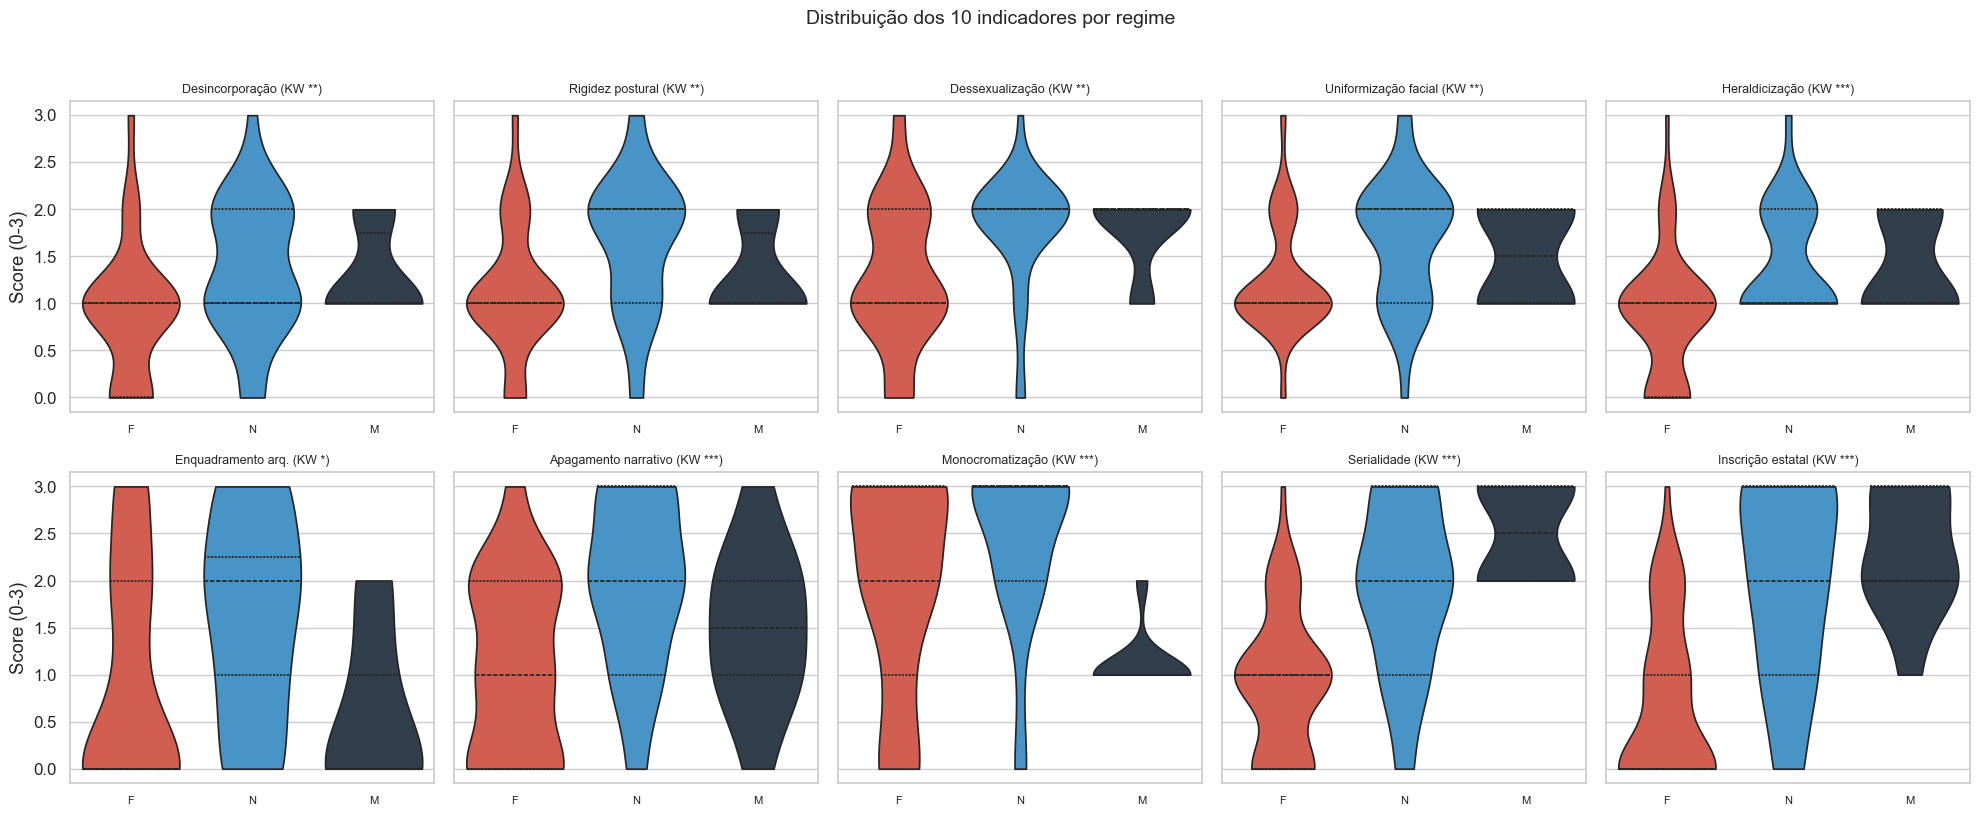

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
palette = {'fundacional': '#e74c3c', 'normativo': '#3498db', 'militar': '#2c3e50'}
for i, ind in enumerate(INDICATORS):
    ax = axes[i // 5, i % 5]
    sns.violinplot(data=df, x='regime_iconocratico', y=ind, order=regimes, palette=palette, ax=ax, inner='quartile', cut=0)
    sig = [r['sig'] for r in results if r['indicator'] == ind][0]
    ax.set_title(f"{INDICATOR_LABELS[ind]} (KW {sig})", fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('' if i % 5 else 'Score (0-3)')
    ax.set_xticklabels(['F','N','M'], fontsize=8)
plt.suptitle('Distribuição dos 10 indicadores por regime', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig_06_violins.png', dpi=150, bbox_inches='tight')
plt.show()